# OptoPatch Cell Location Remapping and Layer position classification
By Debora Masini, 2023

This notebook processes OptoPatch-derived cell position measurements and remaps them from image-based polar coordinates into Allen atlas space for anatomical classification and visualization.

### Overview of Workflow

1. **Input Data**
   - Reads `Positions.xlsx` containing:
     - `Label` (cell ID)
     - `Length` (distance measurement)
     - `Angle` (angle of the line used for distance measurement)
     - `Area patched` (SSp or MOp)
     - `Cell_type` (e.g., PYR, FSI, OTHER)
     - `Ephys_responder` (yes/no)
     - Each cell is measured three times (Repeating Index 1–3). The 3x measurements are respectively: Line from white matter to pia surface. Line from white matter to patched neuron. Line from patched neuron to pia surface. To make these measurements; Each .tif is opened on Imagej. the 
Image is rotated/flip as needed to get cortex pia  surface up and as if always right hemisphere.

2. **Depth Normalization (Image Space)**
   - Computes percentage depth per cell relative to cortex-white matter measured distance.
   - Converts polar coordinates (Length, Angle) to Cartesian coordinates.
   - Visualizes raw cell position in relation to pia reference.

3. **Allen Atlas Geometry Definition**
   - Defines SSp and MOp anchor points in the center of the region in the allen image.
   - Constructs pia (100%) and white matter (0%) contours.
   - Defines cortical layer and ROI polygons (e.g., L1–L6a, SSp, MOp, Complete_area).

4. **Angle-Based Length Projection**
   - Projects rays from SSp or MOp anchors across sampled angles.
   - Computes intersection lengths with the pia contour.
   - Builds an angle-to-Allen radial length lookup table. This table is used on step 5.

5. **Remapping to Allen Space**
   - Scales normalized cell depth (from step2) to Allen radial length(from step4) based on the angle of the line used for distance measurement, does so for for each area (SSp or MOp agle lists).
   - Shifts coordinates to regional Allen anchors.
   - Produces adjusted atlas-space coordinates.

6. **Anatomical Classification** ...Assigns each remapped cell to:
    - Area (SSp or MOp) and links it to its anchor in the Allen
    - Uses distance to determine cortical layer of the patched neuron (L1–L6a)
    - Identifies if a cell falls within the Allen Complete_area or Outside the Allen ROIs
    - Uses polygon containment tests.

7. **Final Output**
   - Plots patch cell (Repeating Index = 2, line from white matter to patched neuron) in Allen space.
   - Marker encodes cell type; color encodes electrophysiological response.
   - Exports:
     - `FINAL_RESULT_Positions.xlsx`
     - `FINAL_Result_Positions.svg`

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
import matplotlib.patches as patches

In [2]:
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)

pandas: 2.2.2
numpy: 1.26.4
matplotlib: 3.9.0


In [ ]:

PROJECT_ROOT = Path(r'...')
positions_file = PROJECT_ROOT / "Positions.xlsx"
results_file = PROJECT_ROOT / "RESULT_Positions.xlsx"


def add_normalized_polar_columns(df: pd.DataFrame,
                                 label_col: str = "Label",
                                 length_col: str = "Length",
                                 angle_col: str = "Angle",
                                 repeats: int = 3) -> pd.DataFrame:
    """
    For each Label:
      - Percentage = Length / max(Length) * 100
      - Average Angle = mean(Angle) repeated for all rows in that Label
    Also:
      - Repeating Index cycles 1..repeats across all rows (3 measurements per cell, index=2 is distance to pia surface)
    """
    required = {label_col, length_col, angle_col}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"Missing required columns: {sorted(missing)}. Found: {list(df.columns)}")

    out = df.copy()
    g = out.groupby(label_col, sort=False)

    out["Percentage"] = g[length_col].transform(lambda x: (x / x.max()) * 100)
    out["Average Angle"] = g[angle_col].transform("mean")
    out["Repeating Index"] = [(i % repeats) + 1 for i in range(len(out))]
    return out

positions_df = pd.read_excel(positions_file)
positions_df = add_normalized_polar_columns(positions_df)

positions_df.to_excel(results_file, index=False)
positions_df.head()

### Minimal Required Input File Structure (`Positions.xlsx`)

The position file must contain the following columns:

- `Label`  
  Unique cell identifier. All three measurements corresponding to the same cell must share the same label.
- `Length`  
  Measured distance (in pixels or µm) along the manually drawn reference line.
- `Angle`  
  Angle (in radians) of the line used for distance measurement, defined relative to the image reference frame.
- `Area patched`  
  Cortical area identifier.
  - `SSp`
  - `MOp`

Each cell must be represented by **exactly three rows**, corresponding to:
1. White matter → pia surface  
2. White matter → patched neuron  
3. Patched neuron → pia surface  

The order of these three rows must be consistent per cell, as repeating indices are assigned sequentially.



- `Cell_type` (e.g., PYR, FSI, OTHER)  
- `Ephys_responder` (yes/no)

These fields are not required for spatial remapping but are used for visualization and classification outputs.

In [ ]:
# Basic correction for cortical depth
# XY in 100x100 frame using Average Angle + Percentage (white matter to pia surface =100%)
radius_max = 100.0

theta = np.deg2rad(positions_df["Average Angle"].to_numpy())
r = (positions_df["Percentage"].to_numpy() / 100.0) * radius_max

positions_df["Angle Radians"] = theta
positions_df["Radius"] = r
positions_df["X"] = r * np.cos(theta)
positions_df["Y"] = r * np.sin(theta)

# Split by repeat index 
dfs_by_repeat = {k: positions_df[positions_df["Repeating Index"].eq(k)] for k in (1, 2, 3)}
df_index_1, df_index_2, df_index_3 = (dfs_by_repeat[1], dfs_by_repeat[2], dfs_by_repeat[3])

positions_df.to_excel(results_file, index=False)
positions_df.head()

In [ ]:
# general check: Create figure for the combined plot of cell depth and a line to the cortical Pia surface as RAW position reads
plt.figure(figsize=(8, 6))

# Plot points for Repeating Index 1 and 2
plt.scatter(df_index_1['X'], df_index_1['Y'], color='blue', label='ctx pia surface')
plt.scatter(df_index_2['X'], df_index_2['Y'], color='green', label='patch cell')

# Draw lines between points with the same label
for label, group_df in positions_df[positions_df['Repeating Index'].isin([1, 2])].groupby('Label'):
    # Only draw a line if both Index 1 and 2 are present for the label
    if len(group_df) == 2:
        plt.plot(group_df['X'], group_df['Y'], color='gray', linestyle='-', linewidth=0.5)

plt.title('RAW Plot of Index 1 (pia surface) and Index 2 (patch cell position)')
plt.xlabel('X Coordinate from DIC image')
plt.ylabel('Y Coordinate from DIC image')
plt.xlim(-10, 110)
plt.ylim(-10, 110)
plt.legend()
plt.grid(True)
plt.show()

### Allen reference geometry

To define the Allen reference geometry, the relevant SVG atlas section was imported from Allen into ImageJ, 
and simplified boundary polygons were manually drawn over the regional contours; 
the resulting vertex coordinates containing polygons contained between 6 and 19 vertices
were then exported and transfered here. 

Of note, the original vectorized SVG contours were geometrically very complex. Hence simplified polygonal boundaries are used. 
Once the final locations are exported (.svg) the two vectors are supperimposed and the simplified vector deleted.

In [ ]:
# Define the Allen coordinates based on allen.svg map import 

# reference point for SSp and MOp
reference_points = {
    'M1_point': (350, 558),
    'S1_point': (596, 412)
}
# reference lines for white matter and Pia surface
lines = {
    '100 Line': [(136, 904), (228, 902), (364, 886), (488, 848), (592, 798), (730, 714), (832, 618), (912, 484), (944, 378), (946, 376)],
    '0 Line': [(240, 600), (302, 572), (388, 530), (454, 504), (478, 494), (566, 450), (624, 392), (672, 326), (706, 246)]
}
# each ALLEN area as a polygon
polygons = {
    'Complete_area': [(116, 896), (220, 592), (416, 514), (550, 452), (640, 360), (702, 254), (946, 376), (900, 502), (812, 638), (680, 748), (492, 846), (320, 894), (146, 906)  ],
    'M1_area': [(124, 898), (236, 592), (346, 540), (460, 494), (450, 856), (326, 892), (222, 904)],
    'S1_area': [(948, 378), (704, 244), (644, 356), (556, 446), (466, 492), (462, 854), (556, 816), (704, 730), (818, 636), (890, 526)],
    'layer-L1': [(184, 900), (186, 904), (188, 880), (286, 866), (432, 828), (538, 790), (666, 718), (782, 626), (858, 524), (906, 402), (918, 360), (944, 376), (884, 536), (800, 656), (656, 764), (492, 846), (314, 894)],
    'layer-L2/3': [(184, 878), (192, 820), (310, 778), (436, 702), (466, 688), (460, 734), (598, 678), (700, 618), (794, 530), (852, 412), (868, 330), (912, 348), (896, 436), (832, 568), (704, 686), (614, 748), (482, 810), (388, 838), (240, 878)],
    'layer-L4': [(460, 730), (462, 688), (608, 612), (680, 566), (748, 498), (804, 404), (846, 312), (872, 324), (832, 454), (768, 560), (624, 660), (530, 704)],
    'layer-L5': [(176, 818), (194, 730), (286, 690), (428, 620), (590, 548), (724, 448), (768, 348), (788, 280), (842, 312), (804, 408), (748, 504), (676, 574), (626, 606), (468, 690), (300, 780), (236, 810)],
    'layer-L6a': [(234, 596), (324, 556), (432, 510), (508, 476), (592, 424), (664, 328), (704, 242), (792, 282), (748, 392), (682, 480), (584, 546), (428, 620), (266, 700), (202, 734)]
}

def plot_data(data, ax, is_line=False):
    for key, points in data.items():
        # Convert points to numpy array for easier handling
        points_np = np.array(points)
        # If it's a line, draw lines between each point
        if is_line:
            ax.plot(points_np[:, 0], points_np[:, 1], '-^', label=key)
        # If it's a polygon, close the loop by repeating the first point at the end
        else:
            ax.plot(np.append(points_np[:, 0], points_np[0, 0]),
                    np.append(points_np[:, 1], points_np[0, 1]), '-o', label=key)

# Create the allen areas as a plot for inspection
fig, ax = plt.subplots(figsize=(10, 10))
plot_data(lines, ax, is_line=True)
plot_data(polygons, ax)
ax.set_xlim(0, 1000)
ax.set_ylim(0, 1000)
ax.set_aspect('equal')
ax.legend()
svg_file_path = r"...ALLEN polygons.svg"
plt.savefig(svg_file_path, format='svg', bbox_inches='tight')
plt.show()
print("Axis adjusted!!!! as 1000x1000 pixels")

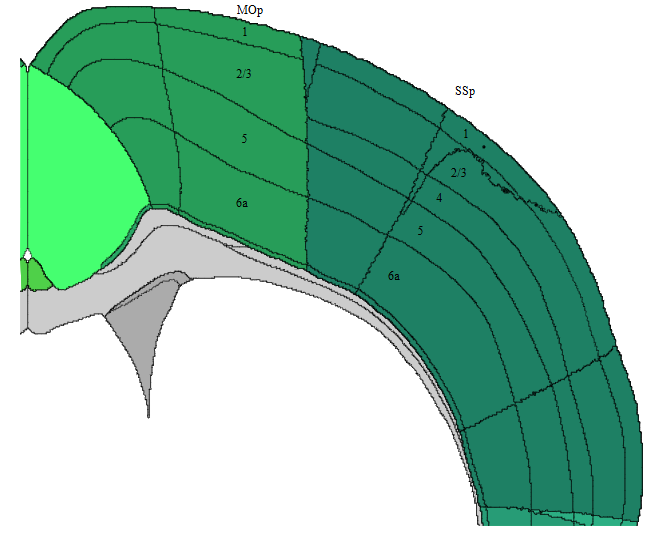


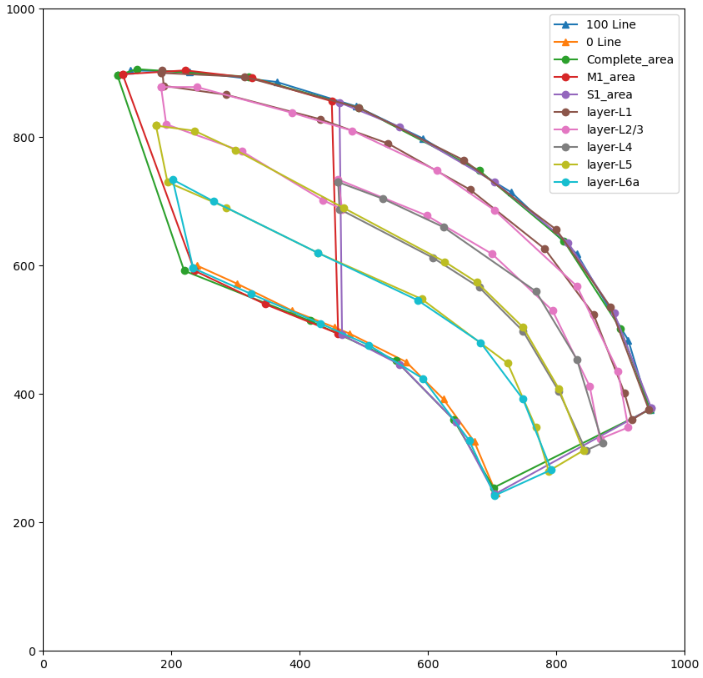



## next
methods like description of steps 4 and 5 : To transform normalized cell depths into atlas space, radial projections were generated from the SSp and MOp reference anchors across a predefined angular range, and the intersection distance between each ray and the pia contour was computed to derive an angle-dependent radial length function. For each cell, the normalized depth was then scaled by the corresponding Allen radial length based on its measurement angle and cortical area, and the resulting coordinates were translated relative to the appropriate regional anchor to obtain final atlas-space positions.

In [ ]:
# In the ALLEN
# Calculating distances from reference points in SSp and MOp to the pia surface; repeat for various line angles
angles_radians = np.arange(0.06, 1.91, 0.02)
line_pts = np.asarray(lines["100 Line"], dtype=float)

def find_nearest_point_and_length(ref_point, angle_rad, line_points):
    dx, dy = np.cos(angle_rad), np.sin(angle_rad)
    denom = dx*dx + dy*dy  # = 1, but keep explicit

    min_dist = np.inf
    best = None
    for px, py in line_points:
        proj = ((px - ref_point[0]) * dx + (py - ref_point[1]) * dy) / denom
        nx = ref_point[0] + proj * dx
        ny = ref_point[1] + proj * dy
        dist = np.hypot(nx - px, ny - py)
        if dist < min_dist:
            min_dist = dist
            best = (nx, ny)

    length = np.hypot(best[0] - ref_point[0], best[1] - ref_point[1])
    return best, length

# Compute and store nearest point + length for various possible line angles
rows = []
for ref_label, ref_point in reference_points.items():
    ref_point = np.asarray(ref_point, dtype=float)
    for angle_rad in angles_radians:
        nearest_point, length = find_nearest_point_and_length(ref_point, angle_rad, line_pts)
        rows.append((ref_label, angle_rad, length, nearest_point[0], nearest_point[1], ref_point[0], ref_point[1]))

angles_df = pd.DataFrame(
    rows,
    columns=["Reference Label", "Angle Radians", "Allen Length",
             "Nearest X", "Nearest Y", "Ref X", "Ref Y"]
)

# Plot for inspection
fig, ax = plt.subplots(figsize=(10, 10))
plot_data(lines, ax, is_line=True)
plot_data(polygons, ax)

for _, r in angles_df.iterrows():
    ax.plot([r["Ref X"], r["Nearest X"]], [r["Ref Y"], r["Nearest Y"]], "-", alpha=0.5)

ax.set_xlim(0, 1000)
ax.set_ylim(0, 1000)
ax.set_aspect("equal")
ax.legend()
plt.show()

angles_df[["Reference Label", "Angle Radians", "Allen Length"]].head()

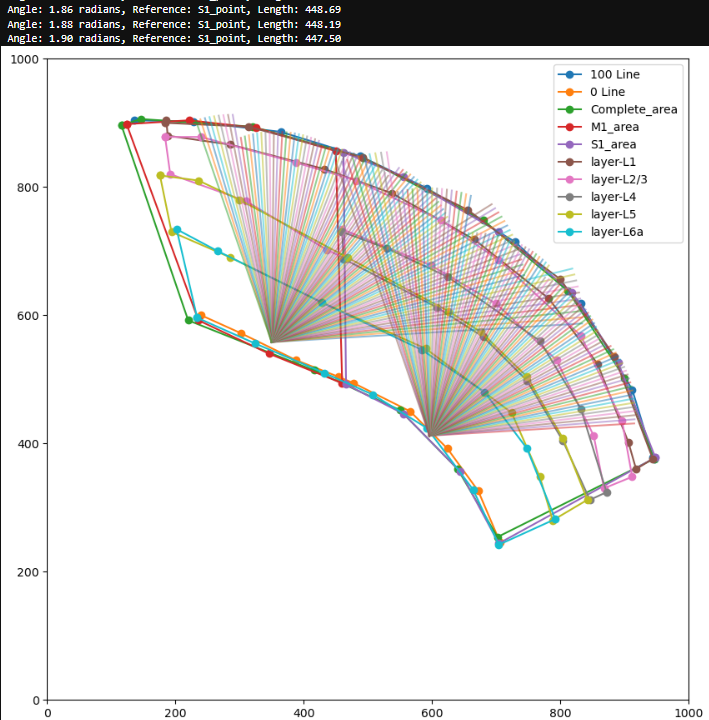



In [ ]:
# a) Build "Reference Point" from Area patched
positions_df["Area patched"] = positions_df["Area patched"].astype(str).str.strip()
positions_df["Reference Point"] = positions_df["Area patched"].map({
    "M1": "M1_point",
    "S1": "S1_point",
})

bad_area = positions_df.loc[positions_df["Reference Point"].isna(), "Area patched"].unique()
if len(bad_area):
    raise ValueError(f"Unexpected 'Area patched' values (cannot map to Reference Point): {bad_area}")


# b) Nearest-angle Allen Length lookup
# Create a fast lookup: for each Reference Label, store arrays of angles + lengths
positions_df["Angle Radians"] = pd.to_numeric(positions_df["Angle Radians"], errors="raise")
angles_df = angles_df.copy()
angles_df["Angle Radians"] = pd.to_numeric(angles_df["Angle Radians"], errors="raise")
angles_df["Reference Label"] = angles_df["Reference Label"].astype(str).str.strip()

# Build per-reference sorted arrays for nearest search
angle_lookup = {}
for ref_label, g in angles_df.groupby("Reference Label", sort=False):
    g2 = g.sort_values("Angle Radians")
    angle_lookup[ref_label] = (
        g2["Angle Radians"].to_numpy(),
        g2["Allen Length"].to_numpy()
    )

def nearest_allen_length(ref_label: str, theta: float) -> float:
    angs, lens = angle_lookup[ref_label]
    idx = np.searchsorted(angs, theta)
    if idx <= 0:
        return float(lens[0])
    if idx >= len(angs):
        return float(lens[-1])
    # choose closest neighbor
    left = idx - 1
    right = idx
    return float(lens[left] if abs(theta - angs[left]) <= abs(theta - angs[right]) else lens[right])

# Vectorized-ish: loop once over rows
ref_arr = positions_df["Reference Point"].to_numpy()
theta_arr = positions_df["Angle Radians"].to_numpy()

allen_len = np.empty(len(positions_df), dtype=float)
for i, (ref_label, th) in enumerate(zip(ref_arr, theta_arr)):
    if ref_label not in angle_lookup:
        raise ValueError(f"Reference '{ref_label}' not found in angles_df['Reference Label']")
    allen_len[i] = nearest_allen_length(ref_label, float(th))

positions_df["Allen Length"] = allen_len

# c) Allen-space remap: New Radius, New X/Y
# Radius is in 0–100 already; convert to Allen length scale
positions_df["New Radius"] = (positions_df["Radius"].to_numpy() / 100.0) * positions_df["Allen Length"].to_numpy()

nr = positions_df["New Radius"].to_numpy()
positions_df["New X"] = nr * np.cos(theta_arr)
positions_df["New Y"] = nr * np.sin(theta_arr)

# d) Shift by Allen reference anchor (vectorized)
ref_x = positions_df["Reference Point"].map(lambda k: reference_points[k][0]).to_numpy(dtype=float)
ref_y = positions_df["Reference Point"].map(lambda k: reference_points[k][1]).to_numpy(dtype=float)
positions_df["Adjusted New X"] = positions_df["New X"].to_numpy() + ref_x
positions_df["Adjusted New Y"] = positions_df["New Y"].to_numpy() + ref_y

# e) Polygon membership (classification)
polygon_paths = {
    name: MplPath(np.asarray(coords, dtype=float))
    for name, coords in polygons.items()
}

def classify_point(x: float, y: float) -> str:
    pt = (x, y)
    hits = [name for name, p in polygon_paths.items() if p.contains_point(pt)]
    return ", ".join(hits) if hits else "Outside"

x_adj = positions_df["Adjusted New X"].to_numpy()
y_adj = positions_df["Adjusted New Y"].to_numpy()
positions_df["Polygons"] = [classify_point(x, y) for x, y in zip(x_adj, y_adj)]

# Save the updated DataFrame over the previous one! 
results_file_path = r"...FINAL_RESULT_Positions.xlsx"
positions_df.to_excel(results_file_path, index=False)

positions_df.head()

### final plot

In [ ]:
def get_marker_and_color(cell_type, ephys_responder):
    marker_map = {"OTHER": "s", "PYR": "^", "FSI": "o"}
    marker = marker_map.get(str(cell_type).strip().upper(), "s")

    resp = str(ephys_responder).strip().lower()
    color = "green" if resp == "yes" else "red"
    return marker, color

def plot_data_with_markers(polygons, points_df, ax):
    # polygons
    for name, verts in polygons.items():
        verts = np.asarray(verts, dtype=float)

        poly_path = MplPath(verts, closed=True)
        patch = patches.PathPatch(poly_path, facecolor="none", edgecolor="black", linewidth=1)
        ax.add_patch(patch)

    # points (vectorized-ish: still iterates rows, but fine for scatter)
    for _, row in points_df.iterrows():
        marker, color = get_marker_and_color(row["Cell_type"], row["Ephys_responder"])
        ax.scatter(
            row["Adjusted New X"], row["Adjusted New Y"],
            marker=marker, c=color, s=180, alpha=0.4
        )

# Plot index 2 (based on distance cell to cortical pia surface)
df_index_2 = positions_df[positions_df["Repeating Index"].eq(2)]

fig, ax = plt.subplots(figsize=(10, 10))
plot_data_with_markers(polygons, df_index_2, ax)

ax.set_title("Green=responder; triangle=PYR, circle=FSI, square=OTHER")
ax.set_xlabel("X pixel value on Allen ROI.png")
ax.set_ylabel("Y pixel value on Allen ROI.png")
ax.set_xlim(0, 1000)
ax.set_ylim(0, 1000)
ax.set_aspect("equal")

svg_file_path = r"...FINAL_Result_Positions.svg"
plt.savefig(svg_file_path, format="svg", bbox_inches="tight")
plt.show()

In [ ]:
# Script end